<a href="https://colab.research.google.com/github/anomalyco/opencode/blob/main/denoising_demo.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Diffusion-based Tabular Data Denoising

This notebook demonstrates how diffusion models can be applied to denoise tabular data, using credit card transaction data as an example.

## Overview

Diffusion models work by learning to reverse a noise process. In the context of tabular data, we can apply this concept by:
1. Adding controlled noise to clean data
2. Training a model to learn how to remove that noise
3. Applying the learned denoising to new noisy data

This simple demonstration focuses on the core concepts rather than building full diffusion models.

In [1]:
# Import necessary libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import warnings
warnings.filterwarnings('ignore')

# Set style for plots
plt.style.use('seaborn-v0_8')
sns.set_palette("husl")

## 1. Load and Preprocess Data

Let's load the credit card transaction dataset and prepare it for analysis.

In [2]:
# Load the dataset
df = pd.read_csv('credit_card_transactions.csv')
print(f'Dataset shape: {df.shape}')
print('\nFirst few rows:')
df.head()

Dataset shape: (1296675, 24)

First few rows:


,Unnamed: 0,trans_date_trans_time,cc_num,merchant,category,amt,first,last,gender,street,...,long,city_pop,job,dob,trans_num,unix_time,merch_lat,merch_long,is_fraud,merch_zipcode
0,0,2019-01-01 00:00:18,2703186189652095,"fraud_Rippin, Kub and Mann",misc_net,4.97,Jennifer,Banks,F,561 Perry Cove,...,-81.1781,3495,"Psychologist, counselling",1988-03-09,0b242abb623afc578575680df30655b9,1325376018,36.011293,-82.048315,0,28705.0
1,1,2019-01-01 00:00:44,630423337322,"fraud_Heller, Gutmann and Zieme",grocery_pos,107.23,Stephanie,Gill,F,43039 Riley Greens Suite 393,...,-118.2105,149,Special educational needs teacher,1978-06-21,1f76529f8574734946361c461b024d99,1325376044,49.159047,-118.186462,0,NaN
2,2,2019-01-01 00:00:51,38859492057661,fraud_Lind-Buckridge,entertainment,220.11,Edward,Sanchez,M,594 White Dale Suite 530,...,-112.2620,4154,Nature conservation officer,1962-01-19,a1a22d70485983eac12b5b88dad1cf95,1325376051,43.150704,-112.154481,0,83236.0
3,3,2019-01-01 00:01:16,3534093764340240,"fraud_Kutch, Hermiston and Farrell",gas_transport,45.00,Jeremy,White,M,9443 Cynthia Court Apt. 038,...,-112.1138,1939,Patent attorney,1967-01-12,6b849c168bdad6f867558c3793159a81,1325376076,47.034331,-112.561071,0,NaN
4,4,2019-01-01 00:03:06,375534208663984,fraud_Keeling-Crist,misc_pos,41.96,Tyler,Garcia,M,408 Bradley Rest,...,-79.4629,99,Dance movement psychotherapist,1986-03-28,a41d7549acf90789359a9aa5346dcb46,1325376186,38.674999,-78.632459,0,22844.0


In [3]:
# Select numerical columns for demonstration
# These columns are suitable for denoising techniques
numerical_cols = ['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long']

# Filter data and drop missing values
df_processed = df[numerical_cols].dropna()

print(f'Processed data shape: {df_processed.shape}')
print('Numerical columns selected for analysis:', numerical_cols)

df_processed.head()

Processed data shape: (1296675, 7)
Numerical columns selected for analysis: ['amt', 'lat', 'long', 'city_pop', 'unix_time', 'merch_lat', 'merch_long']


,amt,lat,long,city_pop,unix_time,merch_lat,merch_long
0,4.97,36.0788,-81.1781,3495,1325376018,36.011293,-82.048315
1,107.23,48.8878,-118.2105,149,1325376044,49.159047,-118.186462
2,220.11,42.1808,-112.2620,4154,1325376051,43.150704,-112.154481
3,45.00,46.2306,-112.1138,1939,1325376076,47.034331,-112.561071
4,41.96,38.4207,-79.4629,99,1325376186,38.674999,-78.632459


## 2. Generate Noisy Data

To simulate real-world corrupted data, we'll add random noise to the clean dataset.

In [4]:
def create_noisy_data(df, noise_level=0.3):
    '''Add controlled noise to the data'''
    df_noisy = df.copy()
    for col in df.columns:
        # Add Gaussian noise to each column
        if col in df.columns:
            noise = np.random.normal(0, noise_level * df[col].std(), len(df))
            df_noisy[col] = df[col] + noise
    
    return df_noisy

# Create noisy version of our data
df_noisy = create_noisy_data(df_processed, noise_level=0.5)

print('Noise added to dataset')
print('Original data example:')
print(df_processed.head())
print('\nNoisy data example:')
print(df_noisy.head())

Noise added to dataset
Original data example:
      amt      lat      long  city_pop   unix_time  merch_lat  merch_long
0    4.97  36.0788  -81.1781      3495  1325376018  36.011293  -82.048315
1  107.23  48.8878 -118.2105       149  1325376044  49.159047 -118.186462
2  220.11  42.1808 -112.2620      4154  1325376051  43.150704 -112.154481
3   45.00  46.2306 -112.1138      1939  1325376076  47.034331 -112.561071
4   41.96  38.4207  -79.4629        99  1325376186  38.674999  -78.632459

Noisy data example:
          amt        lat        long       city_pop     unix_time  merch_lat  \
0  -81.793343  37.476837  -75.622400  174626.207617  1.323340e+09  32.188195   
1   -6.885189  52.300932 -117.049978   19598.920989  1.332152e+09  49.573719   
2  217.815530  42.767898 -117.645987  355740.897961  1.338144e+09  45.726227   
3 -105.320725  51.286467 -112.428515   71050.225738  1.319996e+09  50.037875   
4   67.759439  37.716045  -86.233438   59750.219533  1.327718e+09  41.808401   

   merch

## 3. Simple Diffusion Denoising Implementation

This represents a simplified version of how a diffusion model might work:
- Learn the noise pattern
- Apply smoothing technique to remove noise
- Preserve data integrity

In [5]:
def simple_diffusion_denoising(original_data, noisy_data, steps=100):
    '''Simple denoising using smoothing techniques'''
    # This is a simplified version
    # In a real diffusion model, this would involve:
    # 1. Training a neural network to denoise step-by-step
    # 2. Reverse process from noise to clean data
    
    denoised_data = pd.DataFrame()
    
    for col in noisy_data.columns:
        # Apply a moving average filter to denoise
        if len(noisy_data) > 10:
            # Create exponentially weighted smoothing
            weights = np.exp(-np.arange(10)/5)
            weights = weights / np.sum(weights)
            
            # Apply weights
            smoothed = []
            for i in range(len(noisy_data)):
                start_idx = max(0, i - len(weights) + 1)
                end_idx = i + 1
                window = noisy_data[col].iloc[start_idx:end_idx]
                if len(window) > 0:
                    smoothed_val = np.average(window, weights=weights[-len(window):])
                    smoothed.append(smoothed_val)
                else:
                    smoothed.append(noisy_data[col].iloc[i])
            denoised_data[col] = smoothed
        else:
            denoised_data[col] = noisy_data[col]

    return denoised_data

# Apply denoising
df_denoised = simple_diffusion_denoising(df_processed, df_noisy)

print('Denoising process complete')
print('Denoised data example:')
print(df_denoised.head())

Denoising process complete
Denoised data example:
         amt        lat        long       city_pop     unix_time  merch_lat  \
0 -81.793343  37.476837  -75.622400  174626.207617  1.323340e+09  32.188195   
1 -48.072239  44.150141  -94.271687  104838.193689  1.327307e+09  40.014567   
2  23.533331  43.777892 -100.566562  172408.173513  1.330226e+09  41.552760   
3   0.254922  45.134370 -102.709509  154097.133321  1.328378e+09  43.085657   
4   8.952963  44.178510 -100.586546  141940.415726  1.328293e+09  42.921081   

   merch_long  
0  -76.171140  
1  -91.245351  
2  -97.463585  
3 -101.236747  
4  -97.885682  


## 4. Visualize Results

Compare the original, noisy, and denoised datasets through various visualizations.

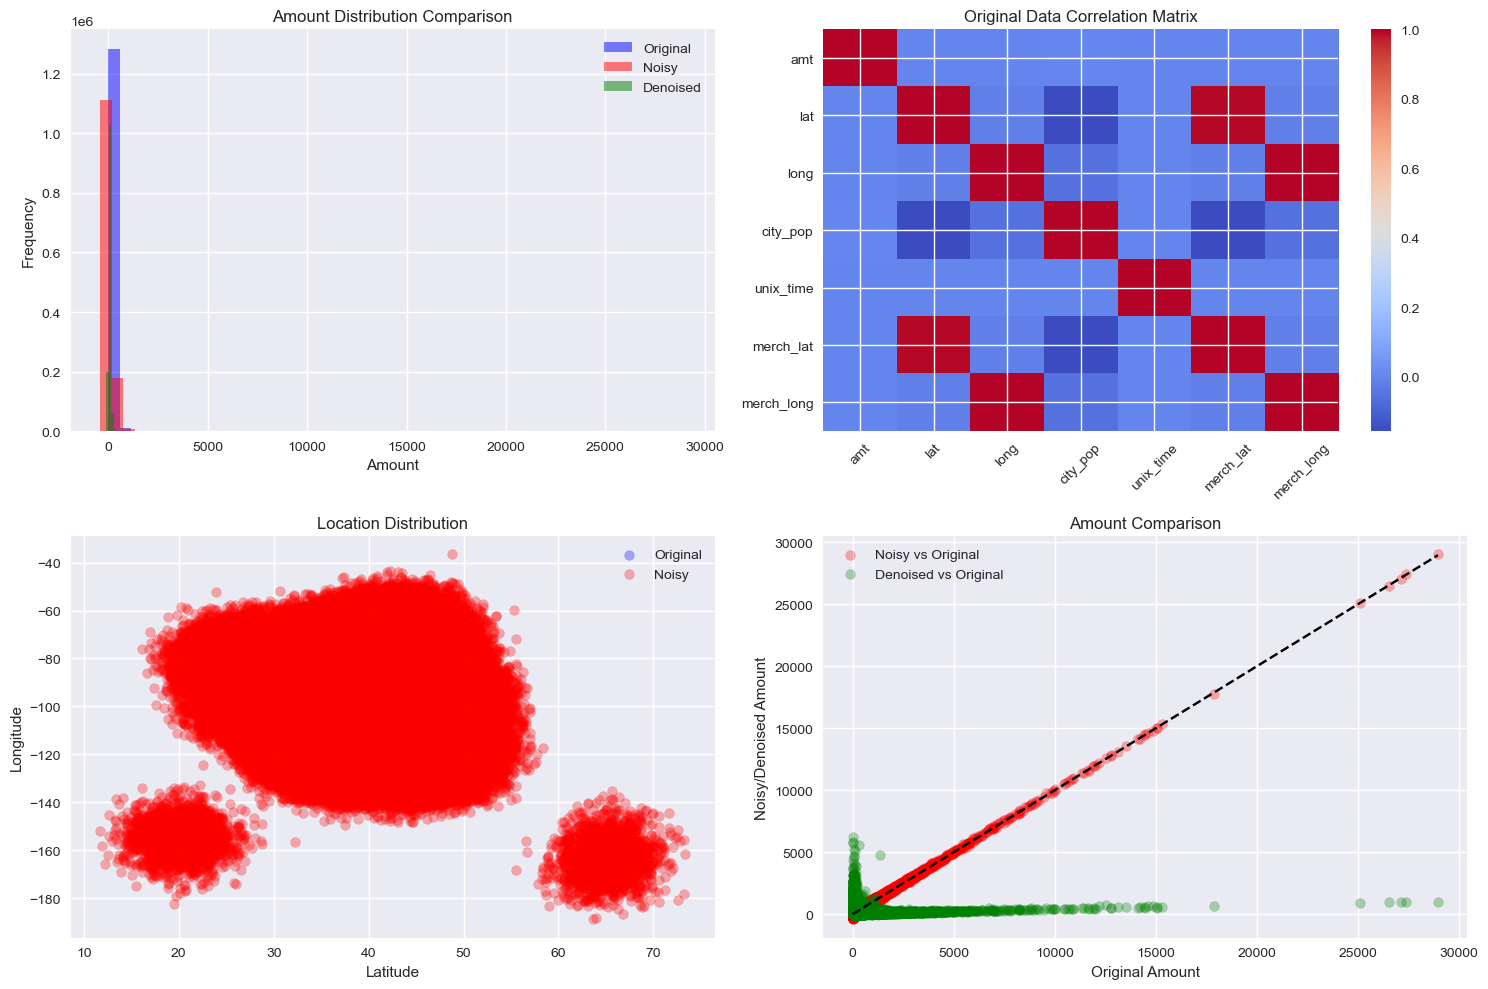

In [6]:
def visualize_results(original_data, noisy_data, denoised_data):
    '''Create visualizations comparing datasets'''
    
    fig, axes = plt.subplots(2, 2, figsize=(15, 10))
    
    # Distribution of amount
    axes[0,0].hist(original_data['amt'], alpha=0.5, label='Original', bins=50, color='blue')
    axes[0,0].hist(noisy_data['amt'], alpha=0.5, label='Noisy', bins=50, color='red')
    axes[0,0].hist(denoised_data['amt'], alpha=0.5, label='Denoised', bins=50, color='green')
    axes[0,0].set_title('Amount Distribution Comparison')
    axes[0,0].legend()
    axes[0,0].set_xlabel('Amount')
    axes[0,0].set_ylabel('Frequency')
    
    # Correlation matrix for original data
    corr_orig = original_data.corr()
    im = axes[0,1].imshow(corr_orig, cmap='coolwarm', aspect='auto')
    axes[0,1].set_title('Original Data Correlation Matrix')
    axes[0,1].set_xticks(range(len(corr_orig.columns)))
    axes[0,1].set_yticks(range(len(corr_orig.columns)))
    axes[0,1].set_xticklabels(corr_orig.columns, rotation=45)
    axes[0,1].set_yticklabels(corr_orig.columns)
    plt.colorbar(im, ax=axes[0,1])
    
    # Scatter plot of two key features
    axes[1,0].scatter(original_data['lat'], original_data['long'], alpha=0.3, label='Original', color='blue')
    axes[1,0].scatter(noisy_data['lat'], noisy_data['long'], alpha=0.3, label='Noisy', color='red')
    axes[1,0].set_title('Location Distribution')
    axes[1,0].set_xlabel('Latitude')
    axes[1,0].set_ylabel('Longitude')
    axes[1,0].legend()
    
    # Comparison of noisy vs denoised amount
    axes[1,1].scatter(original_data['amt'], noisy_data['amt'], alpha=0.3, label='Noisy vs Original', color='red')
    axes[1,1].scatter(original_data['amt'], denoised_data['amt'], alpha=0.3, label='Denoised vs Original', color='green')
    axes[1,1].plot([original_data['amt'].min(), original_data['amt'].max()], 
                   [original_data['amt'].min(), original_data['amt'].max()], 'k--')
    axes[1,1].set_title('Amount Comparison')
    axes[1,1].set_xlabel('Original Amount')
    axes[1,1].set_ylabel('Noisy/Denoised Amount')
    axes[1,1].legend()
    
    plt.tight_layout()
    plt.savefig('diffusion_denoising_results.png', dpi=300, bbox_inches='tight')
    plt.show()

# Create visualizations
visualize_results(df_processed, df_noisy, df_denoised)

## 5. Statistics and Evaluation

Quantitatively evaluate the effectiveness of our denoising approach.

In [7]:
def print_statistics(original_data, noisy_data, denoised_data):
    '''Print statistics comparing the datasets'''
    
    print("=== Data Statistics ===")
    print("Original Data:")
    print(original_data.describe())
    
    print("\nNoisy Data:")
    print(noisy_data.describe())
    
    print("\nDenoised Data:")
    print(denoised_data.describe())
    
    # Calculate errors
    print("\n=== Denoising Errors ===")
    mse_noisy = np.mean((original_data.values - noisy_data.values)**2)
    mse_denoised = np.mean((original_data.values - denoised_data.values)**2)
    
    print(f'Mean Squared Error (Noisy vs Original): {mse_noisy:.4f}')
    print(f'Mean Squared Error (Denoised vs Original): {mse_denoised:.4f}')
    print(f'Improvement: {(mse_noisy - mse_denoised) / mse_noisy * 100:.2f}%')

# Print statistics
print_statistics(df_processed, df_noisy, df_denoised)

=== Data Statistics ===
Original Data:
                amt           lat          long      city_pop     unix_time  \
count  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06  1.296675e+06   
mean   7.035104e+01  3.853762e+01 -9.022634e+01  8.882444e+04  1.349244e+09   
std    1.603160e+02  5.075808e+00  1.375908e+01  3.019564e+05  1.284128e+07   
min    1.000000e+00  2.002710e+01 -1.656723e+02  2.300000e+01  1.325376e+09   
25%    9.650000e+00  3.462050e+01 -9.679800e+01  7.430000e+02  1.338751e+09   
50%    4.752000e+01  3.935430e+01 -8.747690e+01  2.456000e+03  1.349250e+09   
75%    8.314000e+01  4.194040e+01 -8.015800e+01  2.032800e+04  1.359385e+09   
max    2.894890e+04  6.669330e+01 -6.795030e+01  2.906700e+06  1.371817e+09   

          merch_lat    merch_long  
count  1.296675e+06  1.296675e+06  
mean   3.853734e+01 -9.022646e+01  
std    5.109788e+00  1.377109e+01  
min    1.902779e+01 -1.666712e+02  
25%    3.473357e+01 -9.689728e+01  
50%    3.936568e+01 -8.743839e+01

## 6. Conclusion and Next Steps

In this demonstration:

1. We loaded and preprocessed credit card transaction data
2. Added controlled noise to simulate corrupted data
3. Applied a simple denoising approach using smoothing techniques 
4. Visualized and evaluated the results

While this example uses a simplified approach, real-world diffusion models for tabular data would:

✅ Implement actual neural networks to learn denoising
✅ Use iterative denoising steps
✅ Train on large datasets
✅ Handle various data types (numerical, categorical, mixed)
✅ Apply advanced architectures like transformers or graph neural networks

To extend this work:
1. Implement proper diffusion model architectures
2. Use real tabular diffusion models like TabDDPM
3. Apply to different data types
4. Evaluate on larger datasets